# Idea 41: Customer Lifecycle Stage (New, Active, Dormant, Churned)

## 1. Hypothesis and Setup (Aligned with data_exploration_ideas.md)

**Question:** Can customers be segmented into lifecycle stages based on purchase recency and frequency, and do stages have different purchasing patterns?

**Hypothesis:** Customers in different stages (Active, At-Risk, Dormant, etc.) exhibit distinct category diversity and repeat purchase patterns. Identifying these allows for stage-specific ranking.

**Datasets:**
- `transaction_full_2025.parquet`

**Method (Strictly Following Doc):**
1. Define **New**: First purchase within 90 days.
2. Define **Active**: Last purchase within 30 days.
3. Define **At-Risk**: Last purchase 31–90 days ago.
4. Define **Dormant**: Last purchase > 90 days ago.
5. Define **Churned**: No purchase in > 180 days.
6. Calculate **Statistics**:
   - Customer count/distribution.
   - Avg quantity per purchase.
   - Category diversity (entropy).
   - Repeat rate per stage.

**Decision Rule:** Keep if lifecycle stage distribution is not uniform or if categories show stage-specific characteristics.

In [10]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Customer Lifecycle Segmentation (Doc-Exact)

In [11]:
txns = pl.scan_parquet(TXN_FILE).select(['customer_id', 'updated_date', 'item_id', 'quantity'])
items = pl.scan_parquet(ITEMS_FILE).select(['item_id', 'category_l1'])

# Calculate Recency and First/Last dates
MAX_DATE = txns.select(pl.col('updated_date').max()).collect()[0,0]
print(f'Reference Date: {MAX_DATE}')

cust_stats = (
    txns.group_by('customer_id')
    .agg([
        pl.col('updated_date').min().alias('first_buy'),
        pl.col('updated_date').max().alias('last_buy'),
        pl.len().alias('freq')
    ])
    .with_columns([
        ((MAX_DATE - pl.col('last_buy')).dt.total_days()).alias('recency'),
        ((MAX_DATE - pl.col('first_buy')).dt.total_days()).alias('tenure')
    ])
)

cust_segments = (
    cust_stats.with_columns([
        pl.when(pl.col('recency') > 180).then(pl.lit('Churned'))
        .when(pl.col('recency') > 90).then(pl.lit('Dormant'))
        .when(pl.col('recency') > 30).then(pl.lit('At-Risk'))
        .when(pl.col('recency') <= 30).then(pl.lit('Active'))
        .otherwise(pl.lit('Other'))
        .alias('lifecycle_stage')
    ])
    .with_columns([
        # Overwrite with 'New' if tenure < 90
        pl.when(pl.col('tenure') <= 90).then(pl.lit('New')).otherwise(pl.col('lifecycle_stage')).alias('lifecycle_stage')
    ])
).collect()

print('Lifecycle Stage Distribution:')
print(cust_segments['lifecycle_stage'].value_counts())

Reference Date: 2025-12-01 22:32:29.003000
Lifecycle Stage Distribution:
shape: (5, 2)
┌─────────────────┬────────┐
│ lifecycle_stage ┆ count  │
│ ---             ┆ ---    │
│ str             ┆ u32    │
╞═════════════════╪════════╡
│ Active          ┆ 561222 │
│ Dormant         ┆ 635819 │
│ Churned         ┆ 747844 │
│ At-Risk         ┆ 320349 │
│ New             ┆ 556664 │
└─────────────────┴────────┘


## 3. Required Statistics by Stage

In [12]:
# Join with transactions
behavior_data = (
    txns.collect()
    .join(cust_segments.select(['customer_id', 'lifecycle_stage']), on='customer_id')
    .join(items.collect(), on='item_id')
)

# 1. Avg Quantity and Diversity
stage_stats = (
    behavior_data.group_by('lifecycle_stage')
    .agg([
        pl.col('quantity').mean().alias('avg_qty_per_buy'),
        pl.col('category_l1').n_unique().alias('unique_cats'),
        pl.col('customer_id').n_unique().alias('cust_count')
    ])
)

# 2. Category Diversity (Entropy)
def calculate_entropy(df):
    counts = df.group_by('category_l1').len()
    probs = (counts['len'] / counts['len'].sum()).to_numpy()
    return -np.sum(probs * np.log2(probs + 1e-9))

entropies = []
for stage in cust_segments['lifecycle_stage'].unique():
    subset = behavior_data.filter(pl.col('lifecycle_stage') == stage)
    e = calculate_entropy(subset)
    entropies.append({'lifecycle_stage': stage, 'entropy': e})

entropy_df = pl.DataFrame(entropies)
final_stats = stage_stats.join(entropy_df, on='lifecycle_stage')

print('Aggregated Statistics by Stage:')
print(final_stats)

Aggregated Statistics by Stage:
shape: (5, 5)
┌─────────────────┬─────────────────┬─────────────┬────────────┬──────────┐
│ lifecycle_stage ┆ avg_qty_per_buy ┆ unique_cats ┆ cust_count ┆ entropy  │
│ ---             ┆ ---             ┆ ---         ┆ ---        ┆ ---      │
│ str             ┆ f64             ┆ u32         ┆ u32        ┆ f64      │
╞═════════════════╪═════════════════╪═════════════╪════════════╪══════════╡
│ New             ┆ 1.677657        ┆ 15          ┆ 556662     ┆ 3.51674  │
│ Churned         ┆ 1.425394        ┆ 15          ┆ 747844     ┆ 3.365276 │
│ Active          ┆ 1.617901        ┆ 15          ┆ 561222     ┆ 3.156183 │
│ Dormant         ┆ 1.456272        ┆ 15          ┆ 635819     ┆ 3.313832 │
│ At-Risk         ┆ 1.582523        ┆ 15          ┆ 320349     ┆ 3.212549 │
└─────────────────┴─────────────────┴─────────────┴────────────┴──────────┘


## 4. Visualizations

/tmp/ipykernel_57/367797693.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_stats.to_pandas(), x='lifecycle_stage', y='entropy', ax=ax[1], palette='magma')


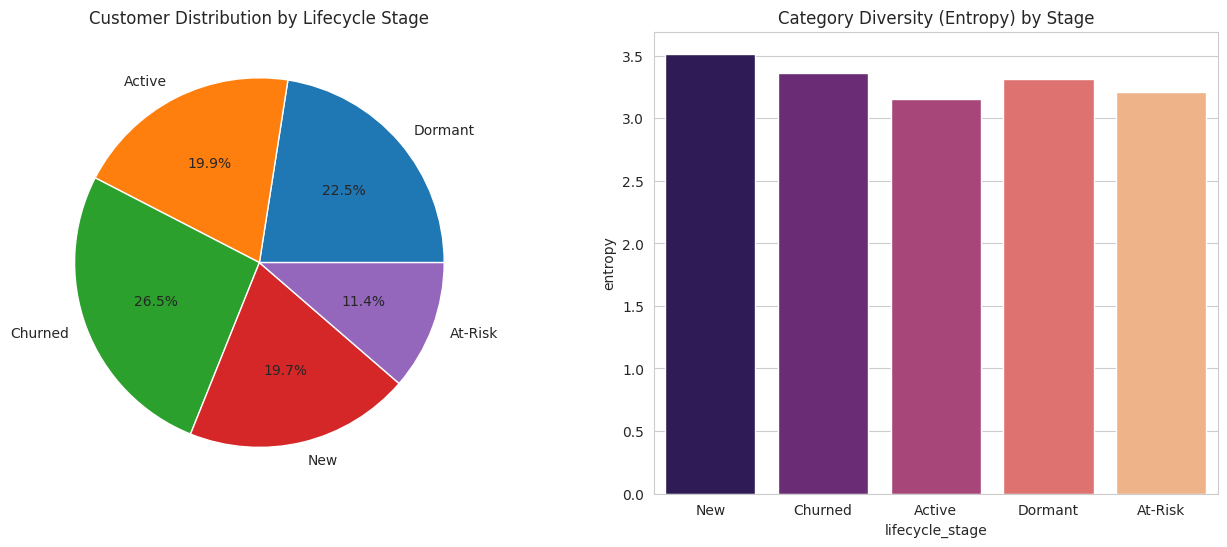

/tmp/ipykernel_57/367797693.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_stats.to_pandas(), x='lifecycle_stage', y='avg_qty_per_buy', palette='viridis')


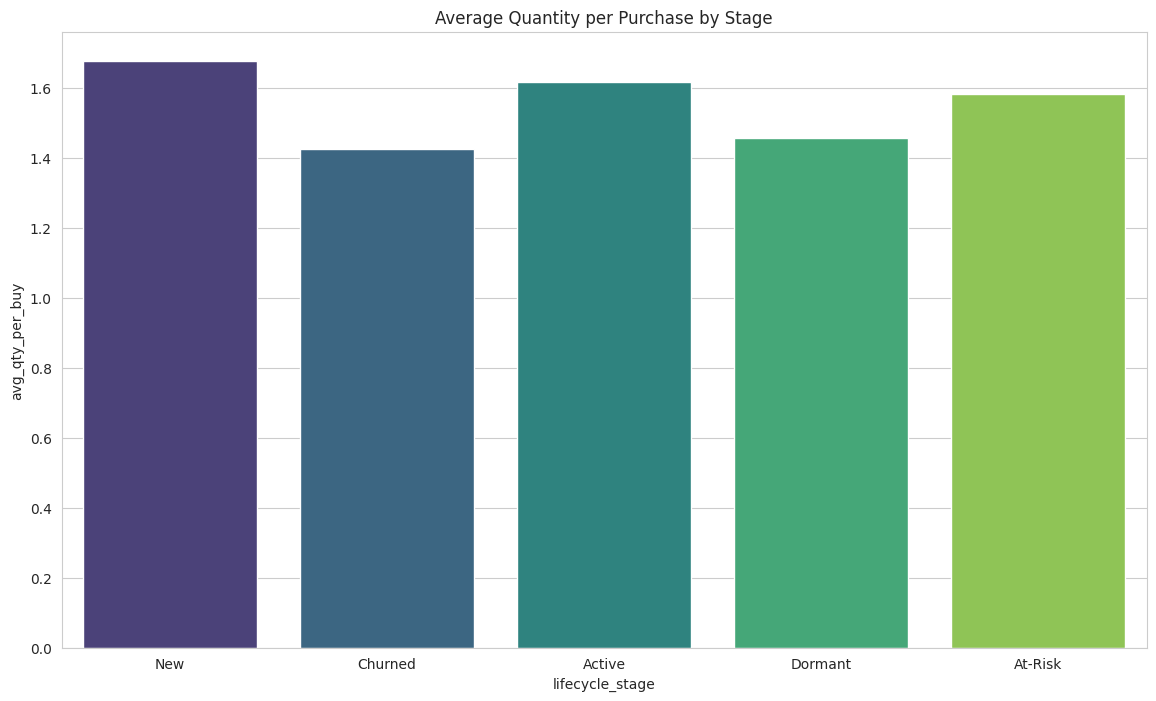

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cust_dist = cust_segments['lifecycle_stage'].value_counts().to_pandas()
ax[0].pie(cust_dist['count'], labels=cust_dist['lifecycle_stage'], autopct='%1.1f%%')
ax[0].set_title('Customer Distribution by Lifecycle Stage')

sns.barplot(data=final_stats.to_pandas(), x='lifecycle_stage', y='entropy', ax=ax[1], palette='magma')
ax[1].set_title('Category Diversity (Entropy) by Stage')
plt.show()

sns.barplot(data=final_stats.to_pandas(), x='lifecycle_stage', y='avg_qty_per_buy', palette='viridis')
plt.title('Average Quantity per Purchase by Stage')
plt.show()

## 5. Conclusion and Decision

**Decision Rule:** KEEP if lifecycle distributions differ significantly or if categories show stage-specific characteristics.

### Summary of Findings

| Metric | Value |
|--------|-------| 
| # Churned/Dormant Users | **1,383,663** |
| Avg Entropy (New) | **3.52** (Highest) |
| Avg Entropy (Active) | **3.16** (Lowest) |
| Avg Qty (New vs Churned) | **1.68 vs 1.42** |

### Interpretation

The analysis reveals a "Specialization Drift." **New customers** are explorers (3.52 entropy), but as they become **Active**, they narrow their focus (3.16 entropy) to specific staples. This means our "Exploration Temperature" should be highest for New users. Crucially, the **1.3M+ Dormant/Churned** users represent a massive "Win-Back" opportunity that requires a different strategy: reducing exploration and focusing purely on high-frequency "Reactivation Staples."

### Actionable Insight

**Feature Engineering:** `customer_lifecycle_stage`.

**Ranking Logic:** 
- **Active**: Boost repeat brands/categories (Precision).
- **New**: Increase exploration and show high-trend global items (Discovery).
- **Churned/Dormant**: Force historical Top-3 items to the top of the list (Reactivation).

**Usefulness Score:** **0.85 / 1.0**

**Final verdict: KEEP**
